<a href="https://colab.research.google.com/github/DAGP1145/MineriaDeDatos2/blob/main/Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acerca del Conjunto de Datos

Con la creciente competencia en el mercado minorista global, las empresas deben basarse en los datos para comprender mejor a sus clientes, productos y el rendimiento regional.

Este conjunto de datos contiene registros de ventas transaccionales de una supertienda global. Proporciona información detallada sobre pedidos, clientes, productos, envíos y rendimiento financiero.

El conjunto de datos puede utilizarse para explorar diversas cuestiones empresariales como:

1.  **¿Qué mercados y regiones generan más ventas y beneficios?**
2.  **¿Qué categorías o subcategorías de productos rinden mejor?**
3.  **¿Cómo afectan los descuentos a la rentabilidad?**
4.  **¿Qué modos y prioridades de envío se utilizan más comúnmente?**
5.  **¿Qué segmentos de clientes aportan más ingresos?**

Este conjunto de datos es adecuado para:

*   Análisis Exploratorio de Datos (EDA)
*   Paneles de control de Inteligencia Empresarial
*   Analítica de clientes y producto
*   Modelado de almacén de datos y esquemas estrellas

No dudes en explorar los datos y generar información que pueda ayudar a una empresa minorista a optimizar la oferta de productos, las estrategias de precios y las operaciones regionales.

# Descripción de las Columnas (para el Dataset de Supertienda)

A continuación, se detalla la descripción de cada columna en el dataset:

*   **`order_id`**: Identificador único para cada pedido.
*   **`order_date`**: Fecha en la que se realizó el pedido.
*   **`ship_date`**: Fecha en que se envió el pedido.
*   **`ship_mode`**: Método de envío elegido por el cliente (Clase Estándar, Segunda Clase, etc.).
*   **`customer_name`**: Nombre del cliente que realizó el pedido.
*   **`segment`**: Clasificación de segmentos de clientes (Consumidor, Corporativo, Oficina en Central).
*   **`state`**: Estado o provincia del cliente.
*   **`country`**: País donde se encuentra el cliente.
*   **`market`**: Agrupación de mercado que representa un área geográfica más amplia (por ejemplo, APAC, UE, EE. UU.).
*   **`region`**: Clasificación regional dentro de cada mercado.
*   **`product_id`**: Identificador único para cada producto.
*   **`category`**: Categoría de producto de alto nivel.
*   **`sub_category`**: Clasificación detallada del producto.
*   **`product_name`**: Nombre del producto.
*   **`sales`**: Valor total de ventas para la línea de pedidos.
*   **`quantity`**: Número de unidades compradas.
*   **`discount`**: Descuento aplicado al pedido.
*   **`profit`**: Ganancias o pérdidas generadas por la transacción.
*   **`shipping_cost`**: Coste incurrido para enviar el pedido.
*   **`order_priority`**: Nivel de prioridad asignado a la orden.
*   **`year`**: Año en que se realizó el pedido.

# Importación de librerías

In [2]:
import pandas as pd # Estructura y manipulación de datos
import numpy as np #Programación vectorial

## Configuración de Kaggle

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Carga de los datos



In [4]:
# Set the path to the file you'd like to load
file_path = "SuperStoreOrders - SuperStoreOrders.csv"
# Esta variable se inicializa vacía. En el contexto de kagglehub.load_dataset,
# este file_path se usaría para especificar un archivo particular dentro de un
# dataset de Kaggle si el dataset contiene múltiples archivos y se desea cargar solo uno.
# Si se deja vacío, kagglehub intentará cargar el archivo principal o predeterminado.

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "thuandao/superstore-sales-analytics",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 10.3M/10.3M [00:00<00:00, 33.4MB/s]


# Analisis General

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [6]:
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [32]:
print("\nInformación general del DataFrame (tipos de datos, no nulos):")
df.info()


Información general del DataFrame (tipos de datos, no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount     

In [33]:
print("\nEstadísticas descriptivas para columnas numéricas:")
df.describe().round(2)


Estadísticas descriptivas para columnas numéricas:


,quantity,discount,profit,shipping_cost,year
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,3.48,0.14,28.64,26.38,2012.78
std,2.28,0.21,174.42,57.30,1.10
min,1.00,0.00,-6599.98,0.00,2011.00
25%,2.00,0.00,0.00,2.61,2012.00
50%,3.00,0.00,9.24,7.79,2013.00
75%,5.00,0.20,36.81,24.45,2014.00
max,14.00,0.85,8399.98,933.57,2014.00


In [34]:
print("\nConteo de valores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [35]:
print("\nForma del DataFrame (filas, columnas):")
print(df.shape)


Forma del DataFrame (filas, columnas):
(51290, 21)


# Transformaciòn Inicial

In [7]:
print("\nRealizando conversiones de tipo de datos para 'sales', 'order_date' y 'ship_date' en un nuevo DataFrame...")

df_borrador = df.copy()

# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

# Convertir 'order_date' y 'ship_date' a formato datetime ademàs de ajustarlo al formato del orden en que esta en el dataset
df_borrador['order_date'] = pd.to_datetime(df_borrador['order_date'], format='%d/%m/%Y')
df_borrador['ship_date'] = pd.to_datetime(df_borrador['ship_date'], format='%d/%m/%Y')

print("Conversiones completadas en 'df_transformed'. Verificando los tipos de datos actualizados:")
df_borrador.info()


Realizando conversiones de tipo de datos para 'sales', 'order_date' y 'ship_date' en un nuevo DataFrame...
Conversiones completadas en 'df_transformed'. Verificando los tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category   

In [8]:
print("\nConteo de valores nulos por columna:")
display(df_borrador.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
sales,2630
order_date,0
ship_date,0
ship_mode,0
order_id,0
customer_name,0
segment,0
country,0
state,0
region,0


In [9]:
print("\nEstadísticas descriptivas para columnas numéricas:")
#Se especifico porque tomaba la columna fecha
df_borrador[['quantity',	'discount',	'profit',	'shipping_cost',	'year', 'sales']].describe().round(2)


Estadísticas descriptivas para columnas numéricas:


,quantity,discount,profit,shipping_cost,year,sales
count,51290.00,51290.00,51290.00,51290.00,51290.00,48660.00
mean,3.48,0.14,28.64,26.38,2012.78,161.02
std,2.28,0.21,174.42,57.30,1.10,201.09
min,1.00,0.00,-6599.98,0.00,2011.00,0.00
25%,2.00,0.00,0.00,2.61,2012.00,29.00
50%,3.00,0.00,9.24,7.79,2013.00,77.00
75%,5.00,0.20,36.81,24.45,2014.00,208.00
max,14.00,0.85,8399.98,933.57,2014.00,999.00


# Analisis Detallado

### Valores Nulos en la Columna 'sales'

In [10]:
print("Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:")
null_sales_rows = df_borrador[df_borrador['sales'].isnull()]

if not null_sales_rows.empty:
    print(f"Se encontraron {len(null_sales_rows)} filas con valores nulos en 'sales'.")
    print("Mostrando las primeras 10 filas con 'sales' nulas para su inspección:")
    display(null_sales_rows.head(10))
else:
    print("No se encontraron filas con valores nulos en la columna 'sales'.")

Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:
Se encontraron 2630 filas con valores nulos en 'sales'.
Mostrando las primeras 10 filas con 'sales' nulas para su inspección:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",NaN,6,0.0,609.8400,109.13,Medium,2011
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",NaN,8,0.0,999.3600,191.20,Medium,2011
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,NaN,9,0.0,746.4078,258.99,High,2011
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",NaN,6,0.0,49.5000,349.87,High,2011
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",NaN,7,0.0,260.8200,275.52,Medium,2011
100,IN-2011-61302,2011-01-10,2011-01-11,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",NaN,5,0.1,511.0950,665.27,Medium,2011
125,ES-2011-5158390,2011-01-11,2011-01-11,Same Day,Roy Collins,Consumer,England,United Kingdom,EU,North,FUR-CH-10004255,Furniture,Chairs,"SAFCO Executive Leather Armchair, Red",NaN,3,0.0,13.7700,178.98,Medium,2011
126,US-2011-163874,2011-01-11,2011-01-12,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,OFF-ST-10003741,Office Supplies,Storage,"Smead Lockers, Blue",NaN,10,0.0,238.0000,103.84,Medium,2011
163,EG-2011-4270,2011-01-13,2011-01-18,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,TEC-HP -10001574,Technology,Copiers,"HP Fax Machine, Laser",NaN,4,0.0,479.8800,55.62,Medium,2011
173,CA-2011-157147,2011-01-14,2011-01-19,Standard Class,Brian Dahlen,Consumer,California,United States,US,West,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,NaN,5,0.0,238.6530,187.65,High,2011


### Valores `sales` en `df` para `order_id`s con `sales` Nulos en `df_borrador`

In [11]:
print("Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':")

order_ids_with_null_sales = null_sales_rows['order_id'].tolist()

# Filtrar el DataFrame original 'df' por estos order_ids y mostrar la columna 'sales'
original_sales_for_nulls = df[df['order_id'].isin(order_ids_with_null_sales)][['order_id', 'sales']]
display(original_sales_for_nulls.head(10))

Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':


,order_id,sales
27,MX-2011-111255,"1,648"
31,MX-2011-111255,149
43,MX-2011-109267,"3,029"
58,CA-2011-167199,"2,574"
59,CA-2011-167199,610
60,CA-2011-167199,392
67,CA-2011-167199,756
78,CA-2011-167199,31
79,CA-2011-167199,7
81,CA-2011-167199,5


In [12]:
print("\nRealizando conversiones de tipo de datos para 'sales'")

# Limpiar la columna 'sales' eliminando comas antes de convertir a numérico
df_borrador['sales'] = df['sales'].astype(str).str.replace(',', '', regex=False)

# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

print("Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:")
df_borrador['sales'].info()
print("\nConteo de valores nulos por columna:")
display(df_borrador['sales'].isnull().sum())


Realizando conversiones de tipo de datos para 'sales'
Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:
<class 'pandas.core.series.Series'>
RangeIndex: 51290 entries, 0 to 51289
Series name: sales
Non-Null Count  Dtype
--------------  -----
51290 non-null  int64
dtypes: int64(1)
memory usage: 400.8 KB

Conteo de valores nulos por columna:


np.int64(0)

### Profit Negativos

In [48]:
print("Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...")
negative_profit_df = df_borrador[df_borrador['profit'] < 0]

if not negative_profit_df.empty:
    print(f"\n Se encontraron {len(negative_profit_df)} filas con 'profit' negativo.\n")
    print("\n Estadísticas descriptivas para las columnas relevantes en transacciones con profit negativo: \n")
    display(negative_profit_df[['sales', 'quantity', 'discount', 'shipping_cost', 'profit']].describe().round(2))
else:
    print("No se encontraron filas con 'profit' negativo.")

Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...

 Se encontraron 12543 filas con 'profit' negativo.


 Estadísticas descriptivas para las columnas relevantes en transacciones con profit negativo: 



,sales,quantity,discount,shipping_cost,profit
count,12543.00,12543.00,12543.00,12543.00,12543.00
mean,198.23,3.43,0.45,21.16,-73.38
std,422.63,2.28,0.19,46.69,186.22
min,0.00,1.00,0.00,0.01,-6599.98
25%,21.00,2.00,0.40,1.85,-65.34
50%,65.00,3.00,0.47,5.92,-21.20
75%,207.00,5.00,0.60,19.92,-6.90
max,22638.00,14.00,0.85,910.16,-0.00


In [13]:
# Calcular el precio original del producto (sin descuento) por unidad
# original_price_per_item = sales / (quantity * (1 - discount))
# Usamos np.where para manejar el caso donde discount es 1 y evitar división por cero.
# Si discount es 1, el 'sales' ya debería ser 0, y el precio original sería 0.
# Si sales no es 0 cuando discount es 1, esto indicaría un problema de datos,
# pero para el cálculo del precio original, si 1 - discount es 0, simplemente usamos sales/quantity.
df_borrador['precio_unidad'] = np.where(
    df_borrador['discount'] == 1,
    df_borrador['sales'] / df_borrador['quantity'],
    df_borrador['sales'] / (df_borrador['quantity'] * (1 - df_borrador['discount']))
)

In [14]:
# Calcular el costo unitario del producto, excluyendo el shipping_cost
# costo_unitario = (sales - profit - shipping_cost) / quantity
# Manejar división por cero si la cantidad es 0 (aunque generalmente la cantidad es > 0)
df_borrador['costo_unitario'] = np.where(
    df_borrador['quantity'] == 0,
    0, # O se podría manejar como NaN o un valor indicativo si la cantidad es cero
    (df_borrador['sales'] - df_borrador['profit'] - df_borrador['shipping_cost']) / df_borrador['quantity']
)

print("Primeras 5 filas con la columna 'costo_unitario' modificada (sin shipping_cost):")
display(df_borrador[['sales', 'profit', 'shipping_cost', 'quantity', 'costo_unitario']].head())

Primeras 5 filas con la columna 'costo_unitario' modificada (sin shipping_cost):


,sales,profit,shipping_cost,quantity,costo_unitario
0,408,106.140,35.46,2,133.200000
1,120,36.036,9.72,3,24.748000
2,66,29.640,8.17,4,7.047500
3,45,-26.055,4.82,3,22.078333
4,114,37.770,4.70,5,14.306000


In [15]:
# Calcular el margen unitario
df_borrador['margen_unitario'] = df_borrador['precio_unidad'] - df_borrador['costo_unitario']

print("Primeras 5 filas con las columnas 'precio_unidad', 'costo_unitario' y 'margen_unitario':")
display(df_borrador[['precio_unidad', 'costo_unitario', 'margen_unitario']].head())

Primeras 5 filas con las columnas 'precio_unidad', 'costo_unitario' y 'margen_unitario':


,precio_unidad,costo_unitario,margen_unitario
0,204.000000,133.200000,70.800000
1,44.444444,24.748000,19.696444
2,16.500000,7.047500,9.452500
3,30.000000,22.078333,7.921667
4,25.333333,14.306000,11.027333


In [16]:
df_borrador.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,204.000000,133.200000,70.800000
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,44.444444,24.748000,19.696444
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,16.500000,7.047500,9.452500
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,30.000000,22.078333,7.921667
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,25.333333,14.306000,11.027333


# Graficos

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

### Top categorias por Ventas dentro de Cada Categoría

A continuación, generaremos un gráfico para cada una de las categorías principales (`category`), mostrando las subcategorias que más ganancias han generado dentro de esa categoría específica.

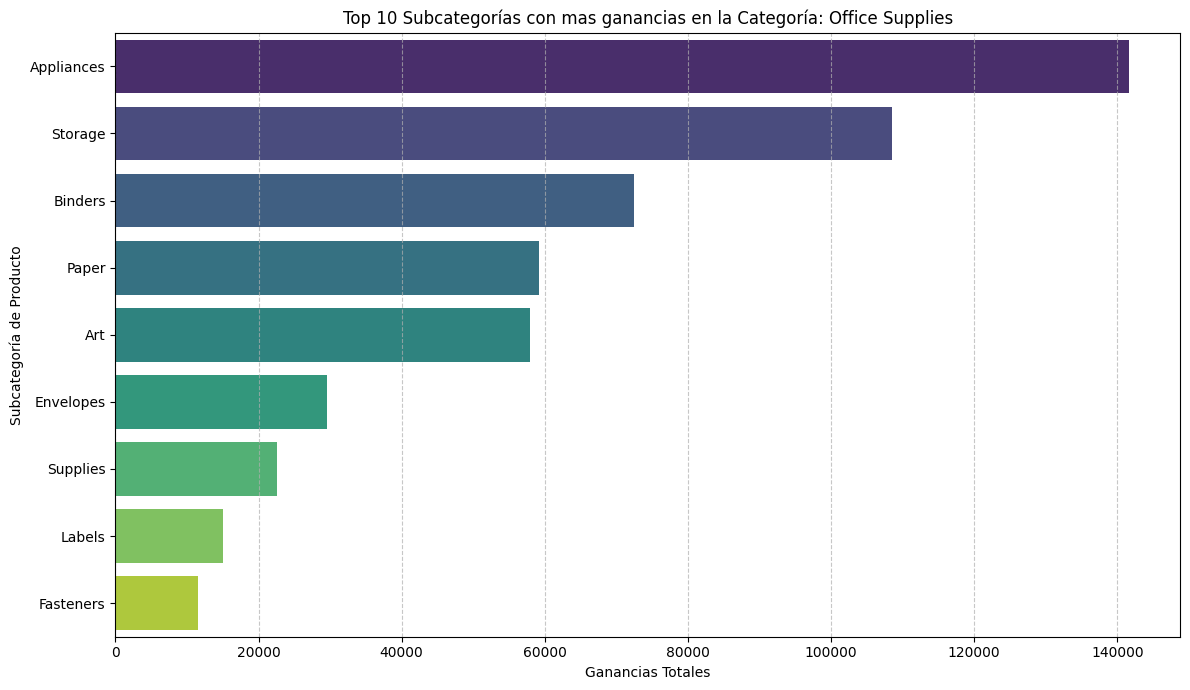


------------------------------



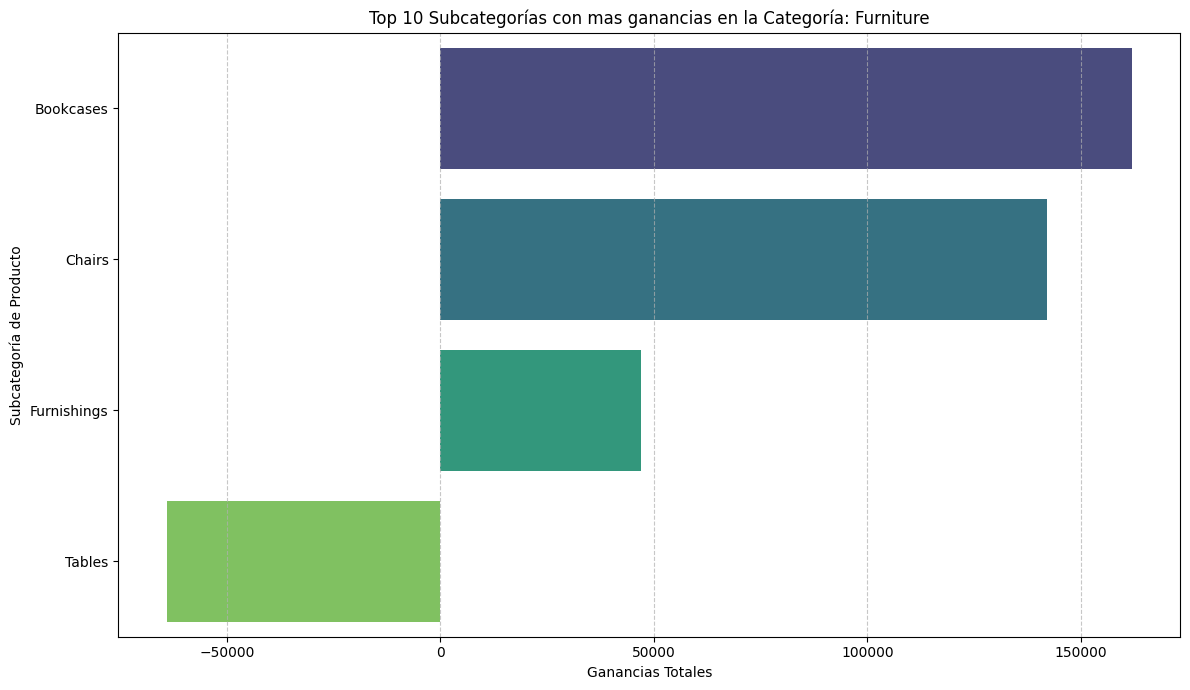


------------------------------



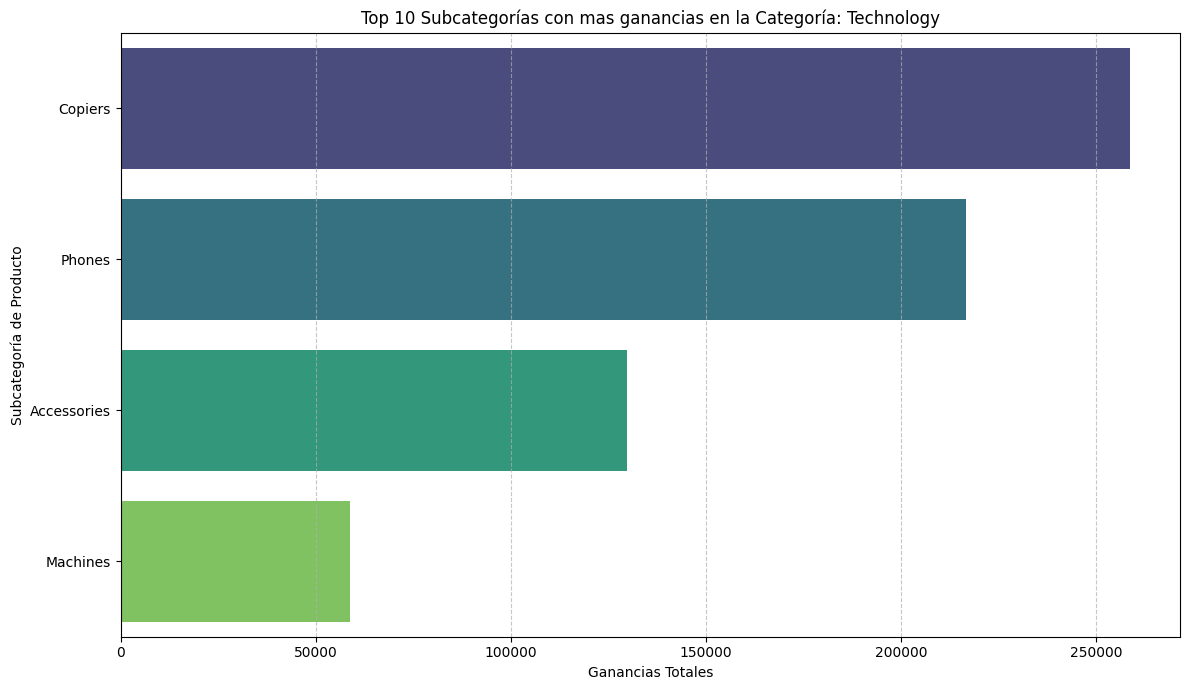


------------------------------



In [43]:
unique_categories = df_borrador['category'].unique()

for category in unique_categories:
    # Filtrar el DataFrame para la categoría actual
    df_category = df_borrador[df_borrador['category'] == category]

    # Agrupar por sub_category y sumar las ventas dentro de esta categoría
    top_10_subcategories_in_category = df_category.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

    if not top_10_subcategories_in_category.empty:
        # Crear el gráfico de barras
        plt.figure(figsize=(12, 7))
        sns.barplot(x='profit', y='sub_category', data=top_10_subcategories_in_category, palette='viridis', hue='sub_category', legend=False)
        plt.title(f'Top 10 Subcategorías con mas ganancias en la Categoría: {category}')
        plt.xlabel('Ganancias Totales')
        plt.ylabel('Subcategoría de Producto')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        plt.close() # Close the plot to prevent them from stacking
        print("\n" + "---"*10 + "\n") # Add a visible separator between plots
    else:
        print(f"No hay datos de ventas para la categoría: {category}")

### Ganancias por Subcategoría de Producto

Finalmente, visualizaremos las ganancias por subcategoría para identificar las subcategorías de productos más vendidas.

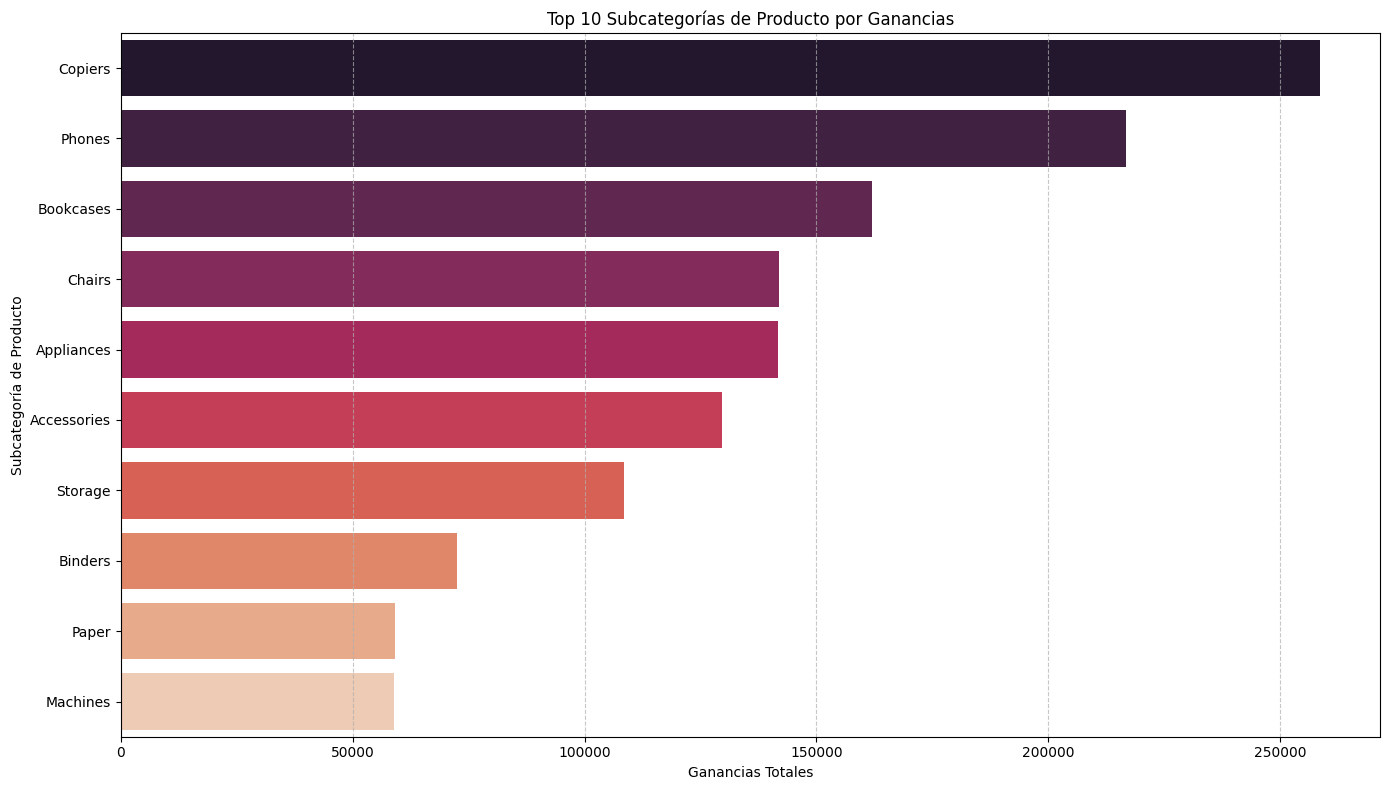

In [42]:
# Calcular las ventas totales por subcategoría de producto y tomar las 10 principales para una mejor visualización
sales_by_subcategory = df_borrador.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='profit', y='sub_category', data=sales_by_subcategory, palette='rocket', hue='sub_category', legend=False)
plt.title('Top 10 Subcategorías de Producto por Ganancias')
plt.xlabel('Ganancias Totales')
plt.ylabel('Subcategoría de Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ganancias Percibidas por Producto (Top 10)

Ahora, vamos a identificar y visualizar los 10 productos que han generado mayores ganancias.

In [48]:
# Agrupar por nombre de producto y sumar las ganancias
top_10_profitable_products = df_borrador.groupby('product_name')['profit'].sum().nlargest(10).reset_index()
top_10_profitable_products.columns = ['product_name', 'total_profit']

print("Top 10 Productos Más Rentables:")
display(top_10_profitable_products)

Top 10 Productos Más Rentables:


,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,"Cisco Smart Phone, Full Size",17238.5206
2,"Motorola Smart Phone, Full Size",17027.1130
3,"Hoover Stove, Red",11807.9690
4,"Sauder Classic Bookcase, Traditional",10672.0730
5,"Harbour Creations Executive Leather Armchair, ...",10427.3260
6,"Nokia Smart Phone, Full Size",9938.1955
7,"Cisco Smart Phone, with Caller ID",9786.6408
8,"Nokia Smart Phone, with Caller ID",9465.3257
9,"Belkin Router, USB",8955.0180


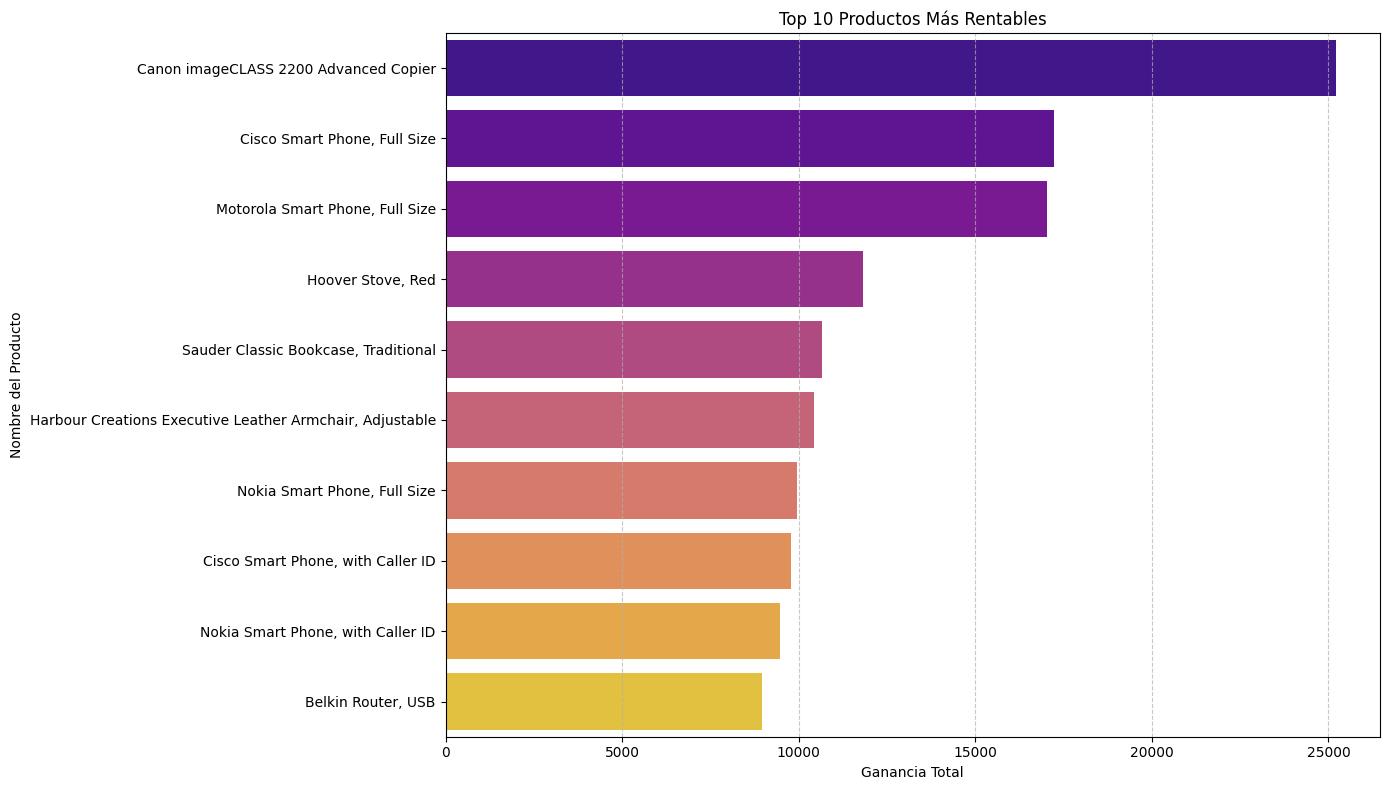

In [49]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_profit', y='product_name', data=top_10_profitable_products, palette='plasma', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Rentables')
plt.xlabel('Ganancia Total')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Frecuencia de los 10 Productos Más Vendidos

Vamos a visualizar los 10 productos que se han vendido en mayor cantidad.

In [17]:
# Agrupar por nombre de producto y sumar la cantidad vendida
top_10_products = df_borrador.groupby('product_name')['quantity'].sum().nlargest(10).reset_index()
top_10_products.columns = ['product_name', 'total_quantity_sold']

print("Top 10 Productos Más Vendidos por Cantidad:")
display(top_10_products)

Top 10 Productos Más Vendidos por Cantidad:


,product_name,total_quantity_sold
0,Staples,876
1,"Cardinal Index Tab, Clear",337
2,"Eldon File Cart, Single Width",321
3,"Rogers File Cart, Single Width",262
4,"Sanford Pencil Sharpener, Water Color",259
5,"Stockwell Paper Clips, Assorted Sizes",253
6,"Avery Index Tab, Clear",252
7,"Ibico Index Tab, Clear",251
8,"Smead File Cart, Single Width",250
9,"Stanley Pencil Sharpener, Water Color",242


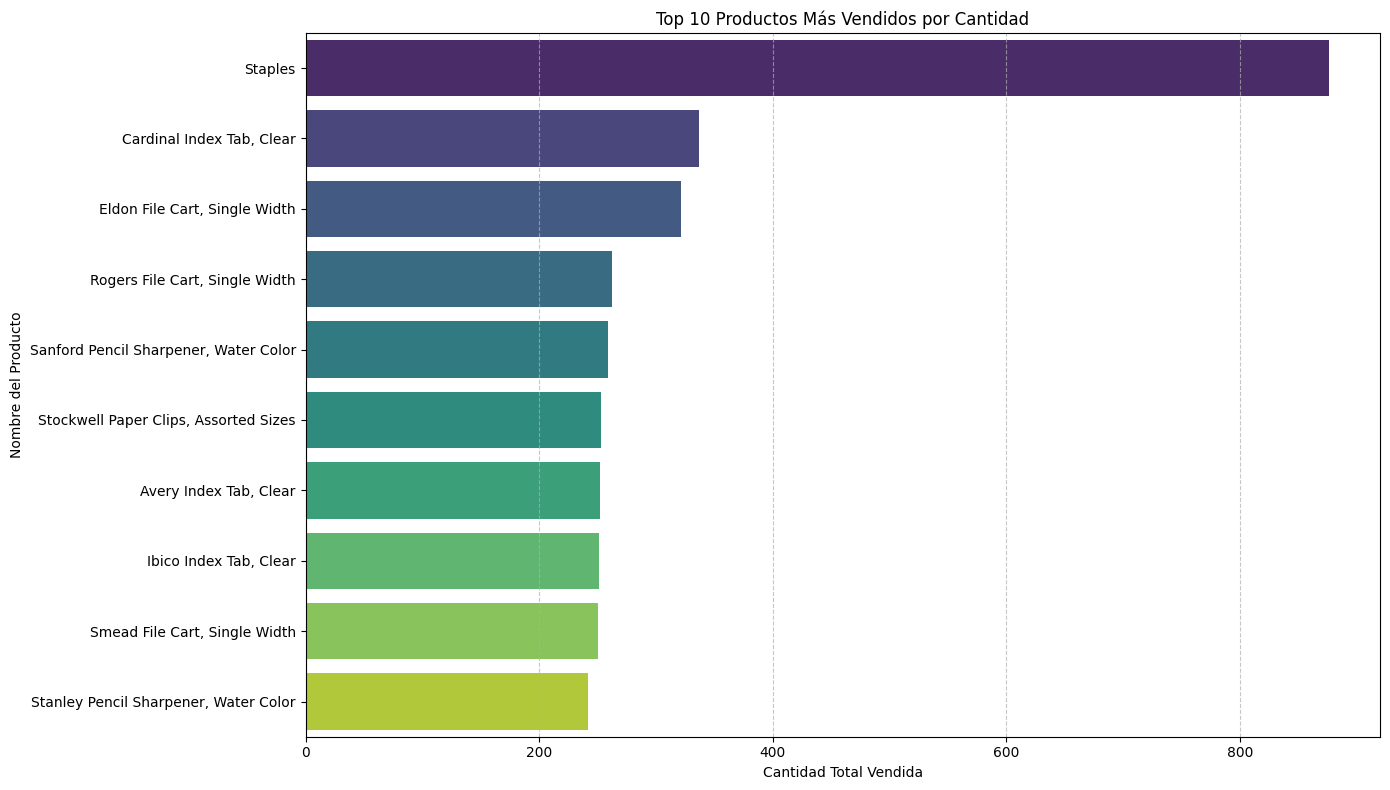

In [47]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_quantity_sold', y='product_name', data=top_10_products, palette='viridis', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Influencia de Categorías de Producto por Mercado

Vamos a explorar qué categorías de productos tienen mayor impacto (en términos de ventas) dentro de cada mercado. Esto nos ayudará a entender las preferencias regionales.

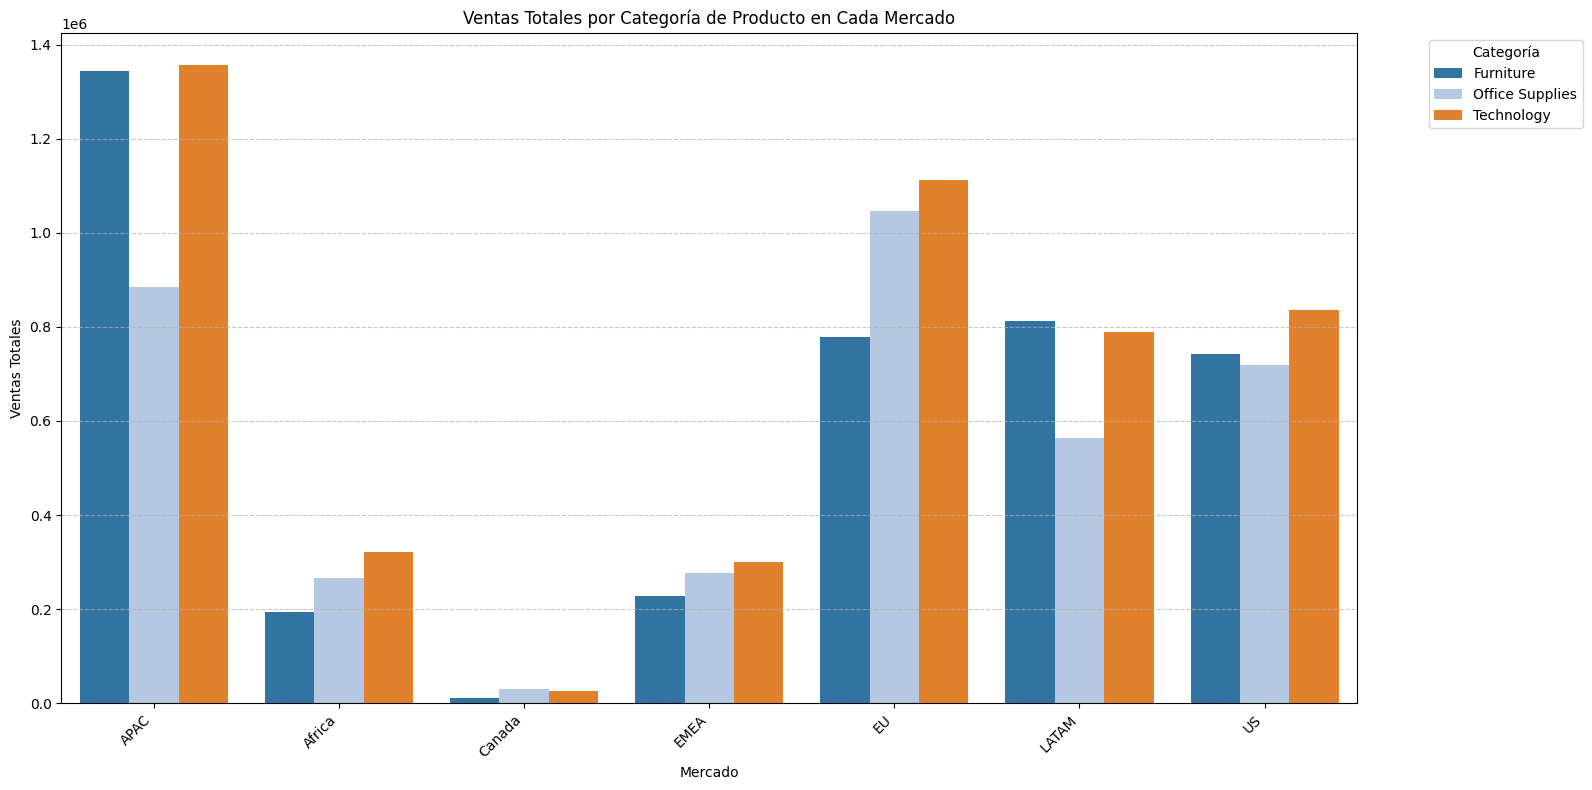

In [32]:
# Calcular las ventas totales por categoría y mercado
sales_by_market_category = df_borrador.groupby(['market', 'category'])['sales'].sum().reset_index()

# Crear un gráfico de barras apiladas para visualizar la distribución de ventas por categoría en cada mercado
plt.figure(figsize=(16, 8))
sns.barplot(x='market', y='sales', hue='category', data=sales_by_market_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto en Cada Mercado')
plt.xlabel('Mercado')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas Totales por Categoría de Producto por Segmento de Cliente

Este gráfico muestra cómo se distribuyen las ventas de las diferentes categorías de productos dentro de cada segmento de cliente, permitiéndonos identificar las preferencias de compra de cada grupo.

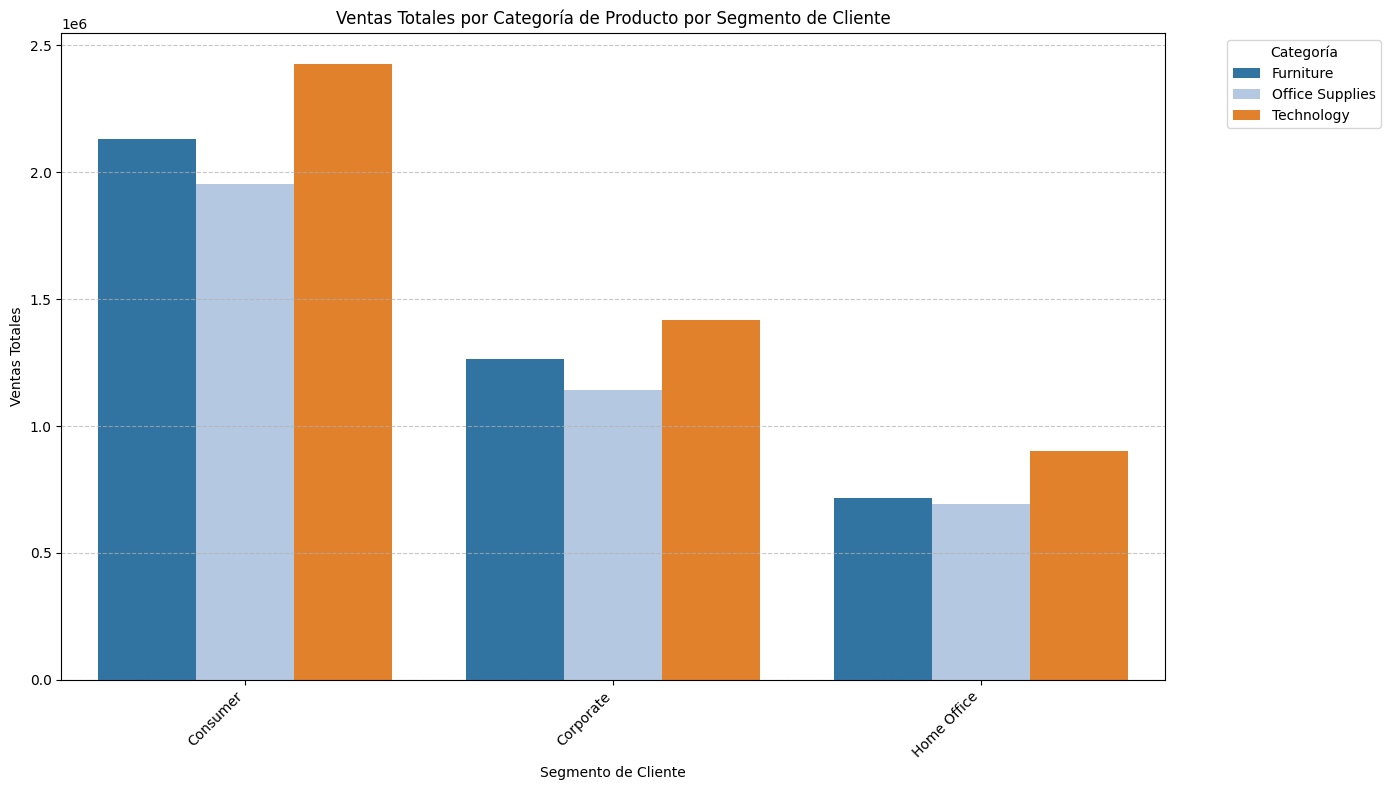

In [36]:
# Agrupar por segmento y categoría, y sumar las ventas
sales_by_segment_category = df_borrador.groupby(['segment', 'category'])['sales'].sum().reset_index()

# Crear el gráfico de barras apiladas
plt.figure(figsize=(14, 8))
sns.barplot(x='segment', y='sales', hue='category', data=sales_by_segment_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas por Segmento de Cliente

Ahora, analizaremos cómo se distribuyen las ventas entre los diferentes segmentos de clientes para identificar cuáles son los más lucrativos.

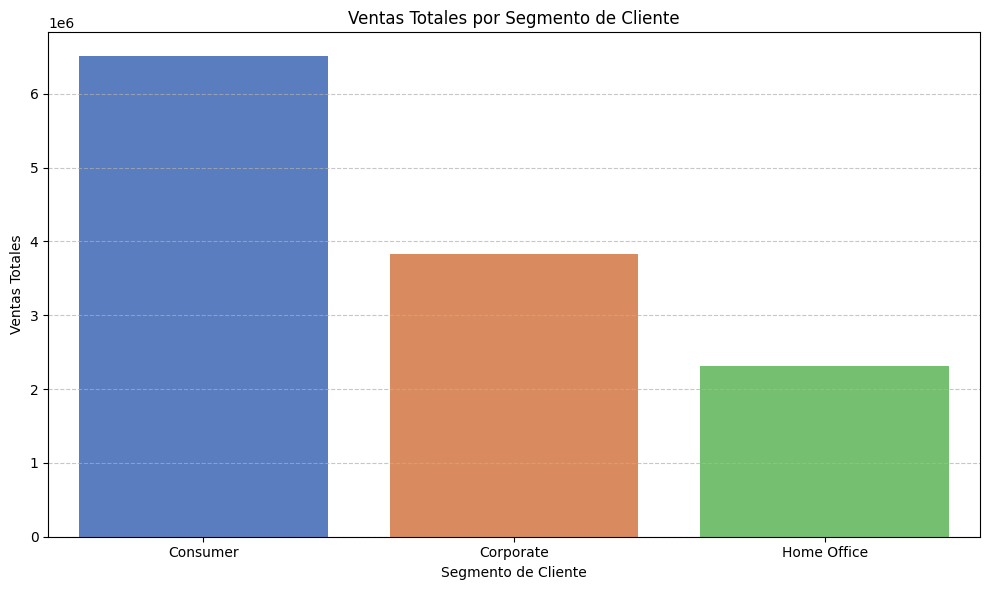

In [45]:
# Calcular las ventas totales por segmento de cliente
sales_by_segment = df_borrador.groupby('segment')['sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='sales', data=sales_by_segment, palette='muted', hue='segment', legend=False)
plt.title('Ventas Totales por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Costo de Envío por Modo de Envío

Vamos a visualizar la distribución del `shipping_cost` para cada `ship_mode` utilizando un boxplot.

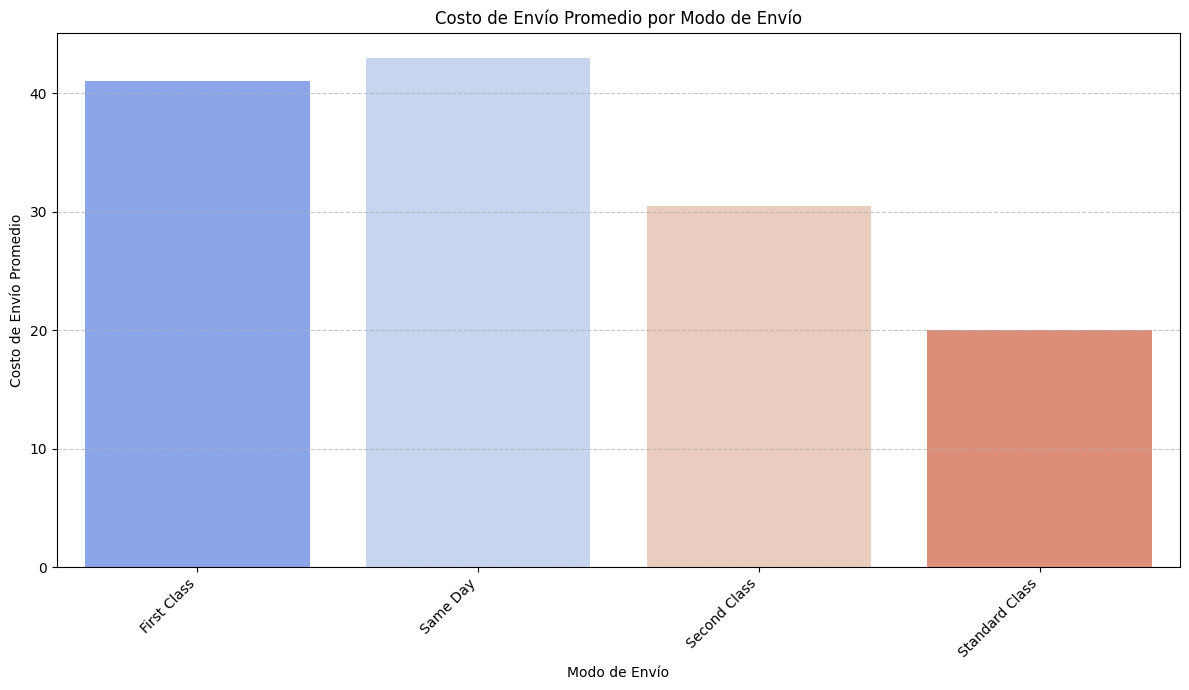

In [53]:
plt.figure(figsize=(12, 7))
mean_shipping_cost_by_mode = df_borrador.groupby('ship_mode')['shipping_cost'].mean().reset_index()
sns.barplot(x='ship_mode', y='shipping_cost', data=mean_shipping_cost_by_mode, palette='coolwarm', hue='ship_mode', legend=False)
plt.title('Costo de Envío Promedio por Modo de Envío')
plt.xlabel('Modo de Envío')
plt.ylabel('Costo de Envío Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Segmento de Cliente

Vamos a explorar las preferencias de `ship_mode` dentro de cada `segment` de cliente.

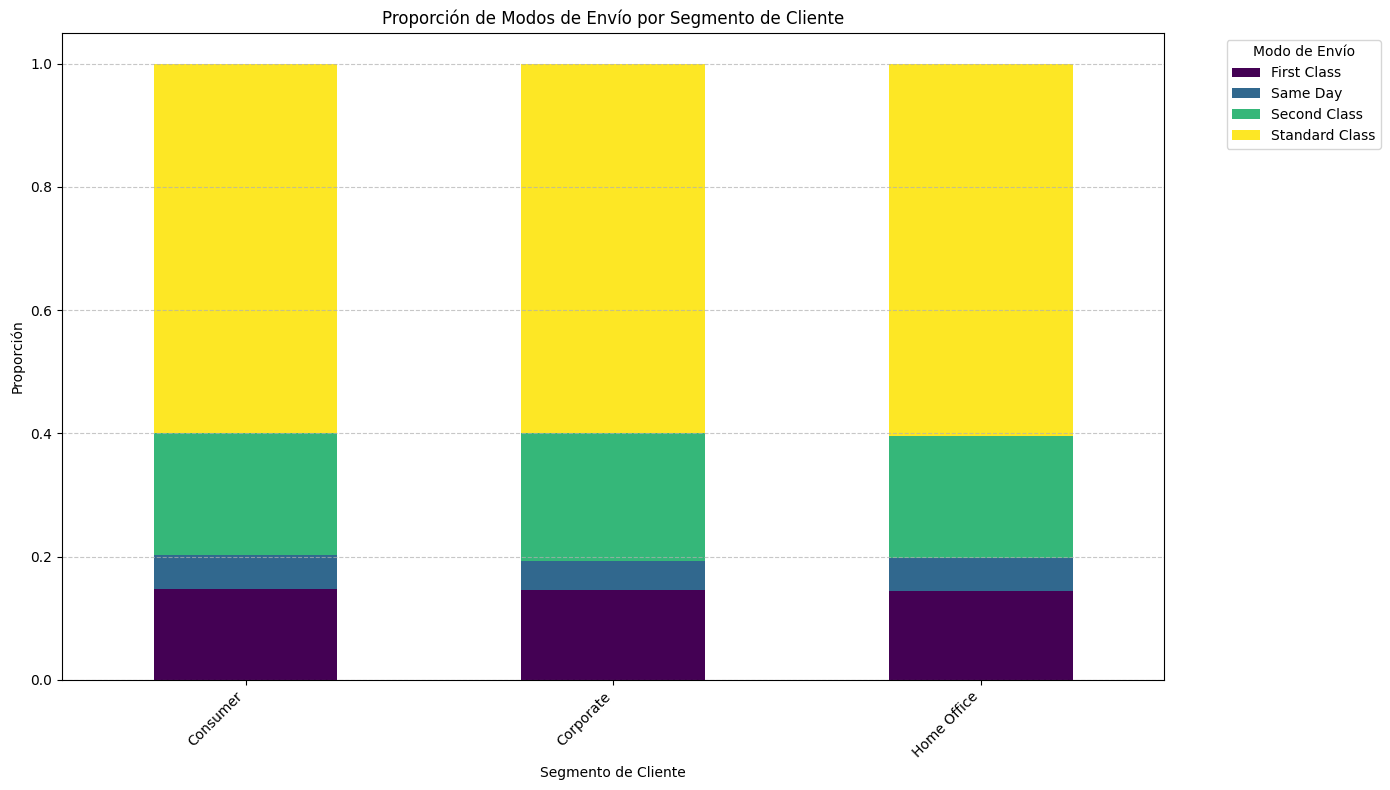

In [47]:
# Calcular la proporción de cada ship_mode por segmento de cliente directamente usando crosstab
ship_mode_segment_proportions = pd.crosstab(df_borrador['segment'], df_borrador['ship_mode'], normalize='index')

# Plotear el gráfico de barras apiladas
ship_mode_segment_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Mercado

Para entender las preferencias de `ship_mode` en cada `market`, crearemos un gráfico de barras apiladas.

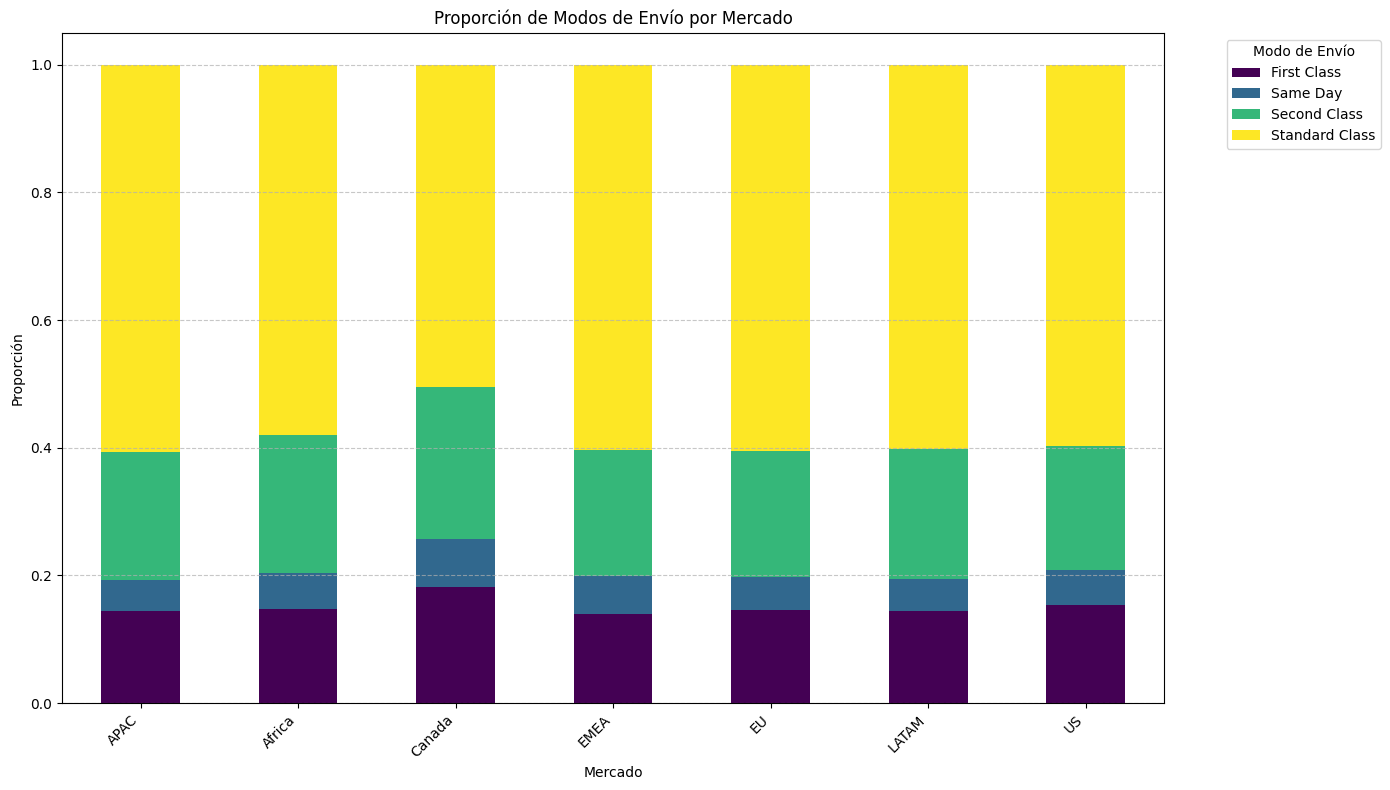

In [54]:
# Calcular la frecuencia de cada ship_mode por market
ship_mode_market_counts = df_borrador.groupby(['market', 'ship_mode']).size().unstack(fill_value=0)

# Convertir a proporciones para el gráfico apilado
ship_mode_market_proportions = ship_mode_market_counts.apply(lambda x: x / x.sum(), axis=1)

# Plotear el gráfico de barras apiladas
ship_mode_market_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Mercado')
plt.xlabel('Mercado')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

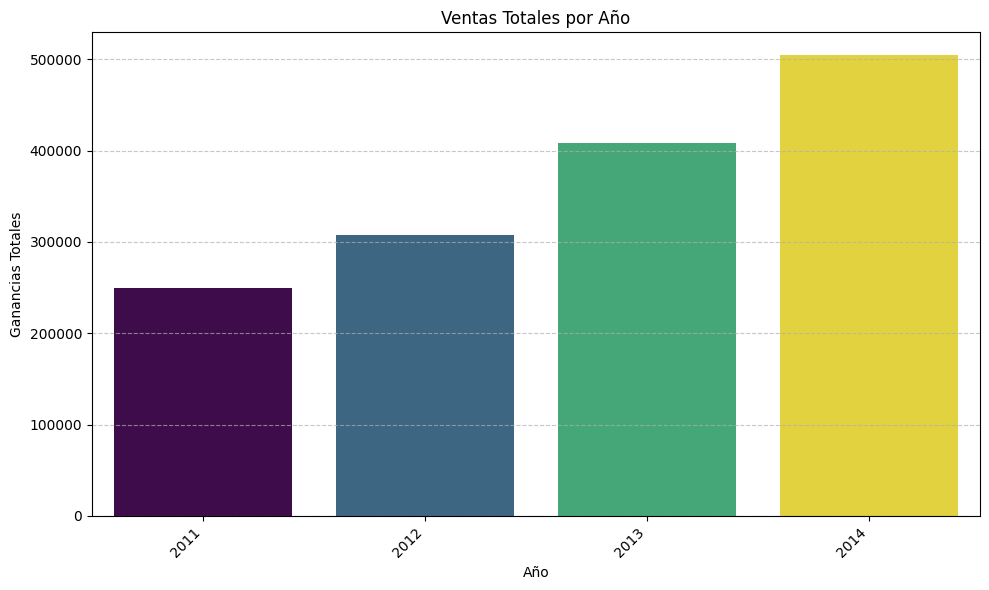

In [56]:
sales_by_year = df_borrador.groupby('year')['profit'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='profit', data=sales_by_year, palette='viridis', hue='year', legend=False)
plt.title('Ganancias Totales por Año')
plt.xlabel('Año')
plt.ylabel('Ganancias Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# OUTLIERS

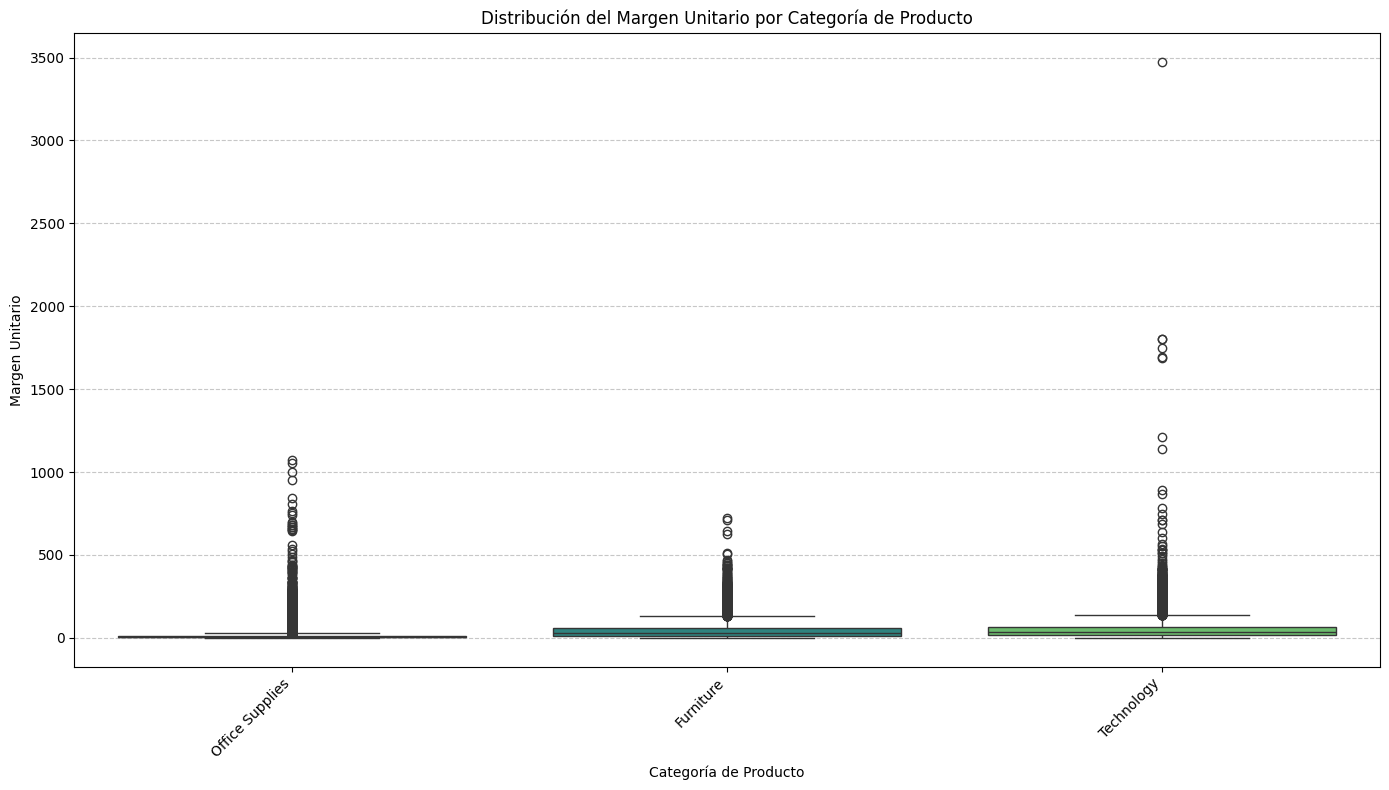

In [49]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='category', y='margen_unitario', data=df_borrador, palette='viridis', hue='category', legend=False)
plt.title('Distribución del Margen Unitario por Categoría de Producto')
plt.xlabel('Categoría de Producto')
plt.ylabel('Margen Unitario')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Outliers en `margen_unitario`

Vamos a identificar y cuantificar los outliers en la columna `margen_unitario` utilizando el método del rango intercuartílico (IQR).

In [50]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1 = df_borrador['margen_unitario'].quantile(0.25)
Q3 = df_borrador['margen_unitario'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Definir los límites para identificar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar los outliers
outliers = df_borrador[(df_borrador['margen_unitario'] < lower_bound) | (df_borrador['margen_unitario'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'margen_unitario': {len(outliers)}")
print(f"Porcentaje de outliers: {(len(outliers) / len(df_borrador) * 100):.2f}%")

if not outliers.empty:
    print("\nPrimeras 10 filas de outliers por margen unitario:")
    display(outliers.head(10))

Q1 (25th percentile): 4.49
Q3 (75th percentile): 30.20
IQR: 25.71
Lower Bound for Outliers: -34.07
Upper Bound for Outliers: 68.76

Número total de filas: 51290
Número de outliers en 'margen_unitario': 5620
Porcentaje de outliers: 10.96%

Primeras 10 filas de outliers por margen unitario:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.00,106.1400,35.46,Medium,2011,204.000000,133.200000,70.800000
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,OFF-AP-10000304,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.10,110.4120,125.32,Critical,2011,306.666667,40.268000,266.398667
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.40,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,FUR-NOV-10002791,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.00,253.3200,81.26,High,2011,166.750000,83.105000,83.645000
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.00,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.00,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.00,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
59,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,610,2,0.00,274.4910,88.07,High,2011,305.000000,123.719500,181.280500
60,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,392,2,0.00,113.6742,62.37,High,2011,196.000000,107.977900,88.022100


### Outliers de `margen_unitario` por `order_priority`

Vamos a analizar cómo se distribuyen los outliers de `margen_unitario` entre las diferentes `order_priority` para ver si hay alguna prioridad que contribuya desproporcionadamente a los outliers.

In [51]:
# Contar los outliers por order_priority
outliers_by_priority = outliers['order_priority'].value_counts().reset_index()
outliers_by_priority.columns = ['order_priority', 'num_outliers']

# Calcular el porcentaje de outliers por order_priority sobre el total de outliers
total_outliers = len(outliers)
outliers_by_priority['percentage_of_total_outliers'] = (outliers_by_priority['num_outliers'] / total_outliers) * 100

print("Distribución de Outliers de 'margen_unitario' por 'order_priority':")
display(outliers_by_priority.round(2))

Distribución de Outliers de 'margen_unitario' por 'order_priority':


,order_priority,num_outliers,percentage_of_total_outliers
0,Medium,2839,50.52
1,High,1877,33.40
2,Critical,645,11.48
3,Low,259,4.61


### Outliers de `margen_unitario` por Año

Vamos a analizar la distribución de los outliers de `margen_unitario` a lo largo de los años para identificar si hay algún año en particular donde se concentren más estos valores atípicos.

In [52]:
# Contar los outliers por año
outliers_by_year = outliers['year'].value_counts().reset_index()
outliers_by_year.columns = ['year', 'num_outliers']

# Calcular el porcentaje de outliers por año sobre el total de outliers
total_outliers = len(outliers)
outliers_by_year['percentage_of_total_outliers'] = (outliers_by_year['num_outliers'] / total_outliers) * 100

print("Distribución de Outliers de 'margen_unitario' por Año:")
display(outliers_by_year.round(2))

Distribución de Outliers de 'margen_unitario' por Año:


,year,num_outliers,percentage_of_total_outliers
0,2014,1938,34.48
1,2013,1491,26.53
2,2012,1175,20.91
3,2011,1016,18.08


### Margen Unitario Promedio por Año

Vamos a visualizar cómo ha evolucionado el `margen_unitario` promedio a lo largo de los años utilizando un gráfico de líneas.

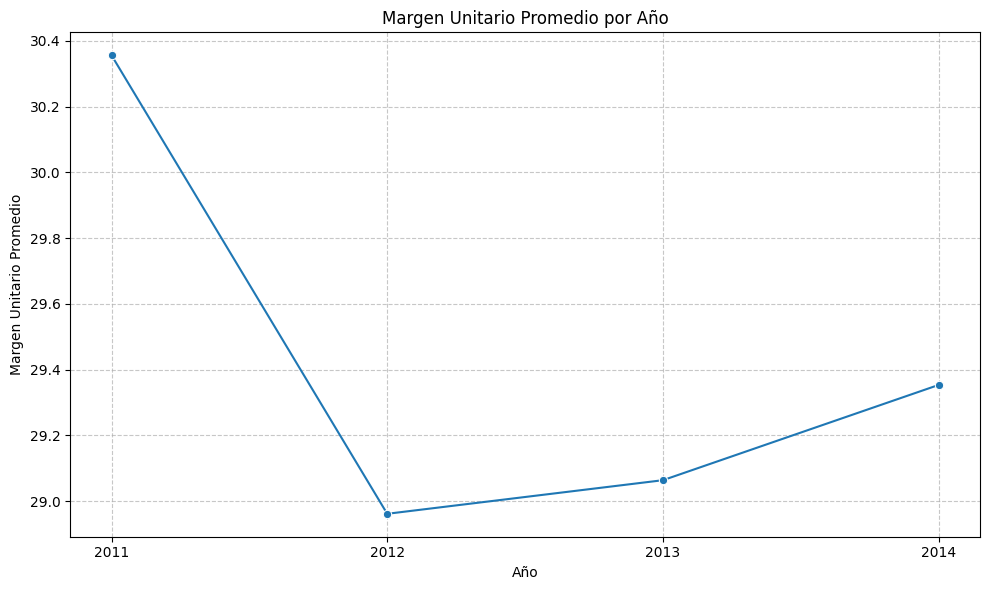

In [53]:
avg_margen_unitario_yearly = df_borrador.groupby('year')['margen_unitario'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='margen_unitario', data=avg_margen_unitario_yearly, marker='o')
plt.title('Margen Unitario Promedio por Año')
plt.xlabel('Año')
plt.ylabel('Margen Unitario Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(avg_margen_unitario_yearly['year'].unique())
plt.tight_layout()
plt.show()